# Visualize Local Thickness Data - Grouped Analysis

This notebook creates histograms comparing treatment groups with mean ± SD distributions.

In [16]:
# Block 1: Parameters

# Input/Output directories
CSV_FOLDER = r"/Users/pavel/Downloads/008_local_thickness_csv"
PLOTS_FOLDER = r"/Users/pavel/Downloads/009_plots_and_statistics"

# Plot settings
X_LIMIT = 100  # Maximum x-axis value (pixels)
Y_LIMIT = 60   # Maximum y-axis value (%)
DPI = 300      # Resolution for saved plots

# Conversion factor (adjust for each experiment)
NM_PER_PIXEL = 43  # nanometers per pixel

# Groups to compare (you can modify these)
GROUPS_TO_PLOT = [
    ("control_A", "LATS wt"),
    ("control_C", "LATS truncation"),
    ("control_A", "LATS-TA"),
    # Add more group comparisons here if needed
]

In [17]:
# Block 2: Import libraries

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
# Block 3: Create output directory

os.makedirs(PLOTS_FOLDER, exist_ok=True)
print(f"Output directory ready: {PLOTS_FOLDER}")

Output directory ready: /Users/pavel/Downloads/009_plots_and_statistics


In [19]:
# Block 4: Define grouping function

def map_group(filename: str):
    """
    Map filename to group name based on first letter.
    
    A -> control_A
    B -> LATS wt
    C -> control_C
    D -> LATS truncation
    E -> LATS-TA
    """
    # Get the first character of the filename
    first_char = filename[0].upper()
    
    if first_char == "A":
        return "control_A"
    elif first_char == "B":
        return "LATS wt"
    elif first_char == "C":
        return "control_C"
    elif first_char == "D":
        return "LATS truncation"
    elif first_char == "E":
        return "LATS-TA"
    
    return None  # Ignore files that don't match

print("Grouping function defined!")

Grouping function defined!


In [20]:
# Block 5: Load and process all CSV files

print("Loading CSV files...")

csv_files = sorted(glob.glob(os.path.join(CSV_FOLDER, "*_LocThk.csv")))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {CSV_FOLDER}")

print(f"Found {len(csv_files)} CSV files\n")

# Load all CSVs and add metadata
all_data = []

for csv_path in csv_files:
    filename = os.path.basename(csv_path)
    group = map_group(filename)
    
    if group is None:
        print(f"Skipping (no group match): {filename}")
        continue
    
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Add metadata columns
    df['image'] = filename
    df['group'] = group
    
    # Calculate bin center
    df['bin_center'] = (df['bin_min'] + df['bin_max']) / 2
    
    all_data.append(df)
    print(f"Loaded: {filename} -> {group}")

# Combine all data
df_all = pd.concat(all_data, ignore_index=True)

print(f"\nTotal rows loaded: {len(df_all)}")
print(f"Groups found: {sorted(df_all['group'].unique())}")
print(f"Images per group:")
print(df_all.groupby('group')['image'].nunique())

Loading CSV files...
Found 4 CSV files

Loaded: A15_ROI000_membrane_LocThk.csv -> control_A
Loaded: A15_ROI001_membrane_LocThk.csv -> control_A
Loaded: E29-ROI-000_membrane_LocThk.csv -> LATS-TA
Loaded: E29-ROI-001_membrane_LocThk.csv -> LATS-TA

Total rows loaded: 200
Groups found: ['LATS-TA', 'control_A']
Images per group:
group
LATS-TA      2
control_A    2
Name: image, dtype: int64


In [21]:
# Block 6: Calculate mean distances per group (from raw data)

print("Calculating mean distances per group...\n")

group_stats = {}

for csv_path in csv_files:
    filename = os.path.basename(csv_path)
    group = map_group(filename)
    
    if group is None:
        continue
    
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Reconstruct all pixel values from histogram
    # For each bin, repeat bin_center by pixel_count times
    bin_centers = (df['bin_min'] + df['bin_max']) / 2
    pixel_values = []
    
    for idx, row in df.iterrows():
        bin_center = (row['bin_min'] + row['bin_max']) / 2
        count = int(row['pixel_count'])
        pixel_values.extend([bin_center] * count)
    
    # Calculate mean for this image
    if len(pixel_values) > 0:
        mean_dist = np.mean(pixel_values)
        
        # Store in group_stats
        if group not in group_stats:
            group_stats[group] = []
        group_stats[group].append(mean_dist)

# Calculate mean and SD for each group
group_mean_sd = {}
for group, distances in group_stats.items():
    group_mean_sd[group] = {
        'mean': np.mean(distances),
        'sd': np.std(distances, ddof=1),  # Sample standard deviation
        'n': len(distances)
    }

print("Group statistics:")
for group, stats in group_mean_sd.items():
    print(f"{group}: {stats['mean']:.2f} ± {stats['sd']:.2f} pixels (n={stats['n']})")

Calculating mean distances per group...

Group statistics:
control_A: 13.08 ± 0.76 pixels (n=2)
LATS-TA: 59.23 ± 1.35 pixels (n=2)


In [22]:
# Block 7: Aggregate data - calculate mean ± SD per group per bin

grp_cols = ["group", "bin_min", "bin_max", "bin_center"]

summary = (df_all
           .groupby(grp_cols, as_index=False)
           .agg(mean_percent=("percentage", "mean"),
                sd_percent=("percentage", "std"),
                n_images=("image", "nunique"))
           .sort_values(["group", "bin_min"])
          )

print(f"Aggregated data: {len(summary)} rows")
print(f"\nSample of aggregated data:")
print(summary.head(10))

Aggregated data: 100 rows

Sample of aggregated data:
     group  bin_min  bin_max  bin_center  mean_percent  sd_percent  n_images
0  LATS-TA      0.0      2.0         1.0      0.000000    0.000000         2
1  LATS-TA      2.0      4.0         3.0      1.367634    0.528109         2
2  LATS-TA      4.0      6.0         5.0      0.291026    0.045883         2
3  LATS-TA      6.0      8.0         7.0      0.179808    0.072143         2
4  LATS-TA      8.0     10.0         9.0      0.351778    0.177335         2
5  LATS-TA     10.0     12.0        11.0      0.581939    0.162362         2
6  LATS-TA     12.0     14.0        13.0      0.650903    0.143599         2
7  LATS-TA     14.0     16.0        15.0      0.955121    0.565421         2
8  LATS-TA     16.0     18.0        17.0      0.940472    0.351351         2
9  LATS-TA     18.0     20.0        19.0      1.023880    0.091007         2


Saved: /Users/pavel/Downloads/009_plots_and_statistics/Histogram_control_A_vs_LATS_wt.png


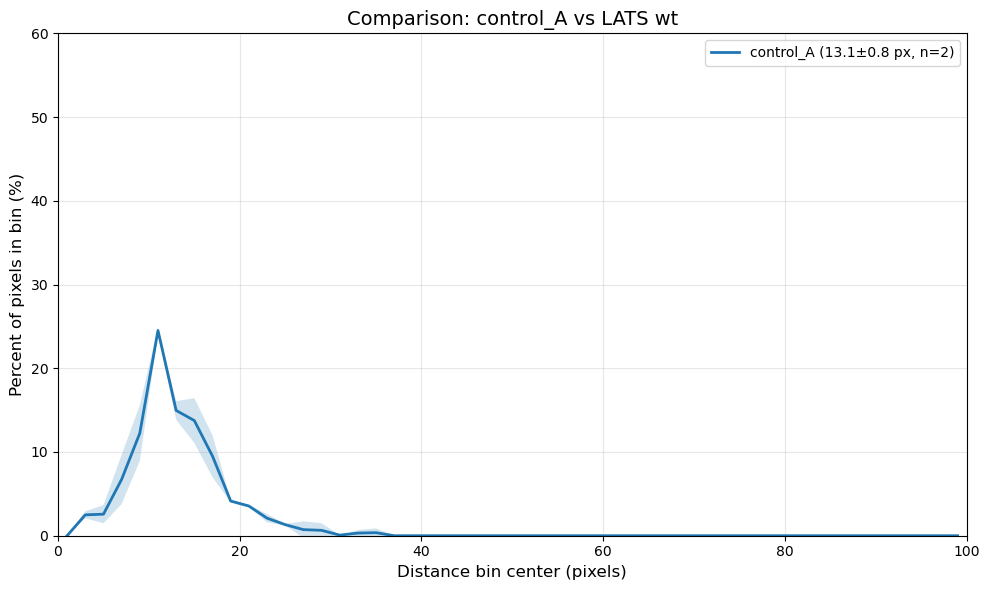

Saved: /Users/pavel/Downloads/009_plots_and_statistics/Histogram_control_C_vs_LATS_truncation.png


/var/folders/tr/7dchvdpj1rz7rn93spmsxls40000gn/T/ipykernel_85986/218725909.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=10)


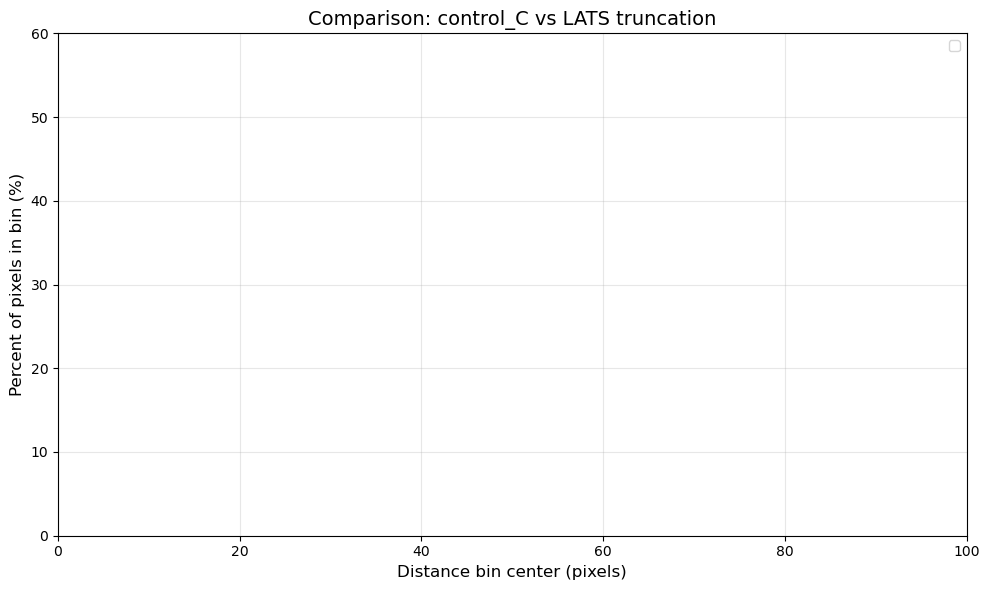

Saved: /Users/pavel/Downloads/009_plots_and_statistics/Histogram_control_A_vs_LATS-TA.png


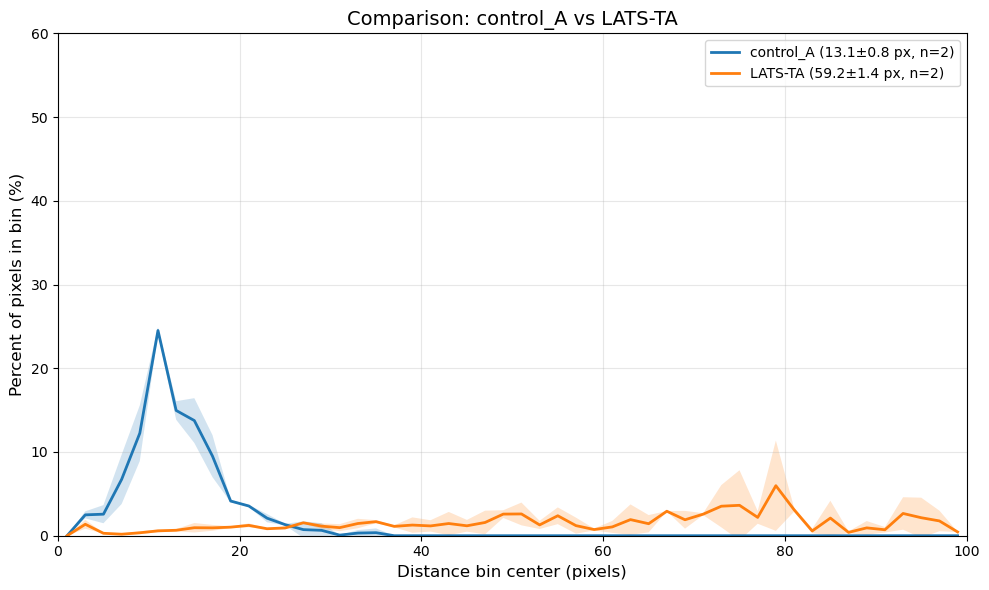


All plots generated!


In [23]:
# Block 8: Create comparison plots

for group_pair in GROUPS_TO_PLOT:
    plt.figure(figsize=(10, 6))
    
    for group_name in group_pair:
        # Get data for this group
        g = summary[summary["group"] == group_name]
        
        if g.empty:
            print(f"Warning: No data found for group '{group_name}'")
            continue
        
        x = g["bin_center"].values
        y = g["mean_percent"].values
        ysd = g["sd_percent"].fillna(0.0).values  # if only one image, SD can be NaN
        
        # Get mean ± SD for this group
        if group_name in group_mean_sd:
            mean_val = group_mean_sd[group_name]['mean']
            sd_val = group_mean_sd[group_name]['sd']
            n_val = group_mean_sd[group_name]['n']
            label = f"{group_name} ({mean_val:.1f}±{sd_val:.1f} px, n={n_val})"
        else:
            label = f"{group_name} (n={int(g['n_images'].max())})"
        
        # Line (mean) + band (±SD)
        plt.plot(x, y, label=label, linewidth=2)
        plt.fill_between(x, y - ysd, y + ysd, alpha=0.2)
    
    plt.xlabel("Distance bin center (pixels)", fontsize=12)
    plt.ylabel("Percent of pixels in bin (%)", fontsize=12)
    plt.xlim(0, X_LIMIT)
    plt.ylim(0, Y_LIMIT)
    
    # Create title from group names
    title = f"Comparison: {' vs '.join(group_pair)}"
    plt.title(title, fontsize=14)
    
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the plot
    filename = f"Histogram_{'_vs_'.join([g.replace(' ', '_') for g in group_pair])}.png"
    out_png = os.path.join(PLOTS_FOLDER, filename)
    plt.savefig(out_png, dpi=DPI)
    print(f"Saved: {out_png}")
    
    plt.show()

print("\nAll plots generated!")

/var/folders/tr/7dchvdpj1rz7rn93spmsxls40000gn/T/ipykernel_85986/552281062.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', fontsize=10)


Saved: /Users/pavel/Downloads/009_plots_and_statistics/Histogram_Untreated_Control_vs_LATS2_OE.png


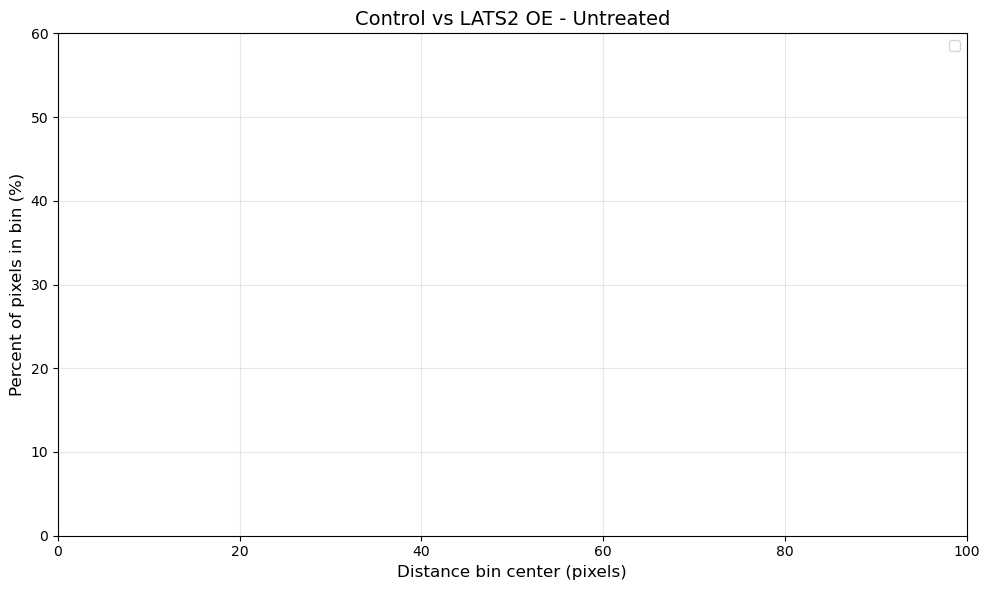

Saved: /Users/pavel/Downloads/009_plots_and_statistics/Histogram_TDI_Control_vs_LATS2_OE.png


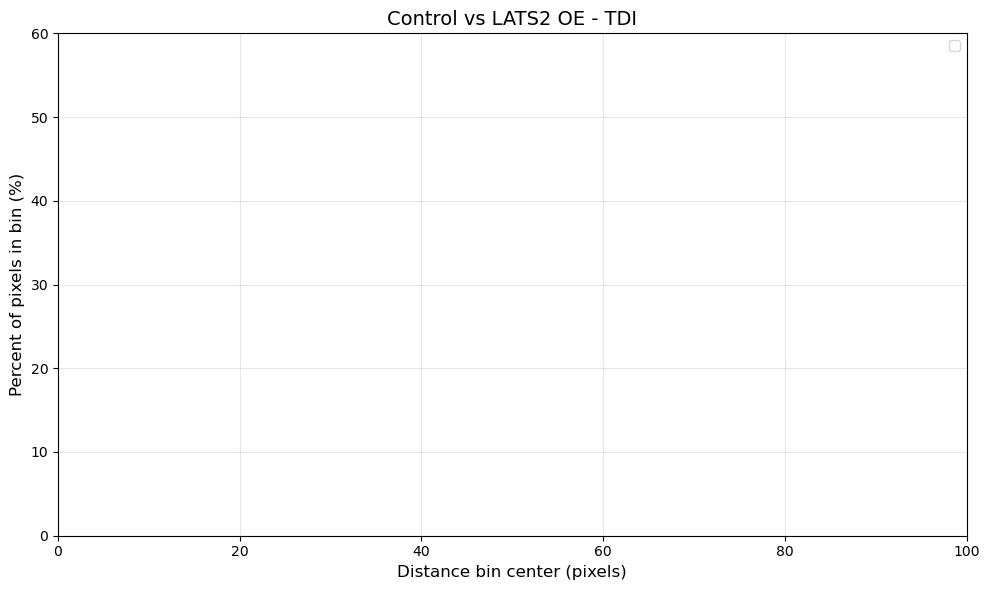

Saved: /Users/pavel/Downloads/009_plots_and_statistics/Histogram_DMSO_Control_vs_LATS2_OE.png


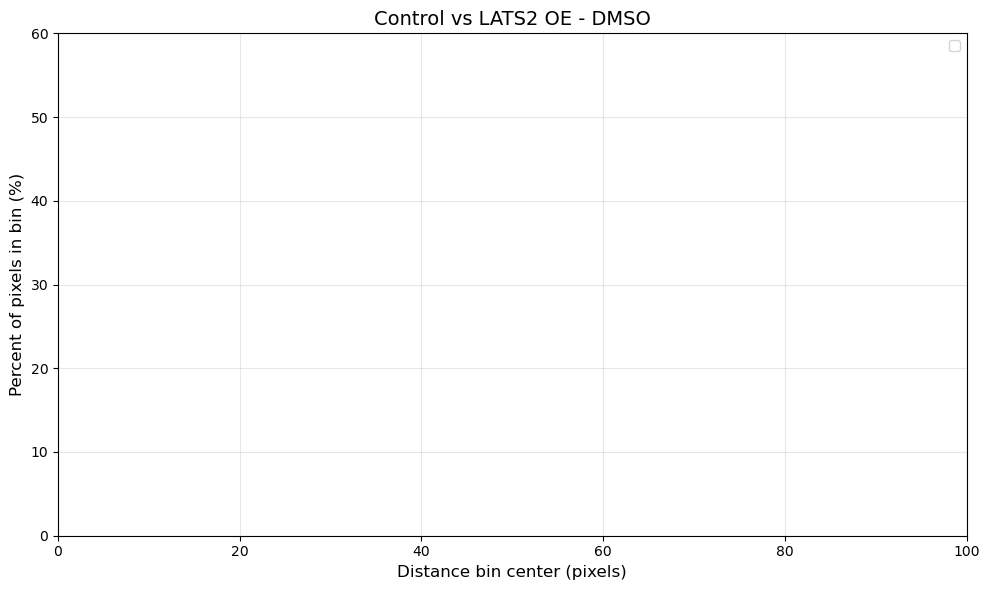

Saved: /Users/pavel/Downloads/009_plots_and_statistics/Histogram_GA_Control_vs_LATS2_OE.png


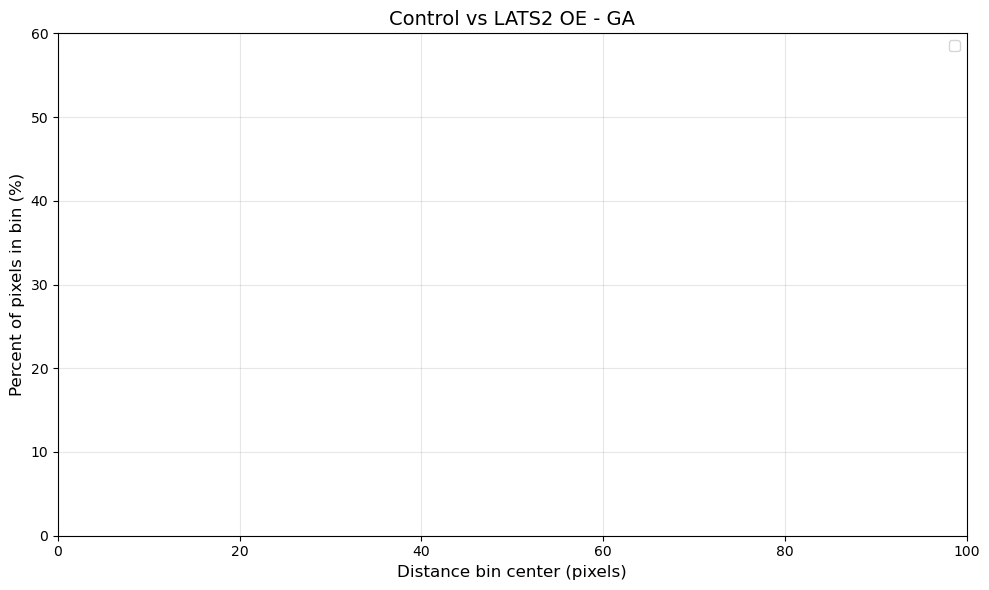


All treatment-specific plots generated!


In [24]:
# Block 9: Plot Control vs LATS2 OE for each treatment

# Define treatment pairs (Control vs LATS2 OE for each treatment)
treatment_pairs = [
    ("Control", "LATS2 OE", "Untreated"),
    ("Control TDI", "LATS2 OE TDI", "TDI"),
    ("Control DMSO", "LATS2 OE DMSO", "DMSO"),
    ("Control GA", "LATS2 OE GA", "GA"),
]

for control_group, lats2_group, treatment_name in treatment_pairs:
    plt.figure(figsize=(10, 6))
    
    for group_name in [control_group, lats2_group]:
        # Get data for this group
        g = summary[summary["group"] == group_name]
        
        if g.empty:
            print(f"Warning: No data found for group '{group_name}'")
            continue
        
        x = g["bin_center"].values
        y = g["mean_percent"].values
        ysd = g["sd_percent"].fillna(0.0).values  # if only one image, SD can be NaN
        
        # Get mean ± SD for this group
        if group_name in group_mean_sd:
            mean_val = group_mean_sd[group_name]['mean']
            sd_val = group_mean_sd[group_name]['sd']
            n_val = group_mean_sd[group_name]['n']
            label = f"{group_name} ({mean_val:.1f}±{sd_val:.1f} px, n={n_val})"
        else:
            label = f"{group_name} (n={int(g['n_images'].max())})"
        
        # Line (mean) + band (±SD)
        plt.plot(x, y, label=label, linewidth=2)
        plt.fill_between(x, y - ysd, y + ysd, alpha=0.2)
    
    plt.xlabel("Distance bin center (pixels)", fontsize=12)
    plt.ylabel("Percent of pixels in bin (%)", fontsize=12)
    plt.xlim(0, X_LIMIT)
    plt.ylim(0, Y_LIMIT)
    
    # Create title from treatment name
    title = f"Control vs LATS2 OE - {treatment_name}"
    plt.title(title, fontsize=14)
    
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the plot
    filename = f"Histogram_{treatment_name}_Control_vs_LATS2_OE.png"
    out_png = os.path.join(PLOTS_FOLDER, filename)
    plt.savefig(out_png, dpi=DPI)
    print(f"Saved: {out_png}")
    
    plt.show()

print("\nAll treatment-specific plots generated!")

In [25]:
# Block 10: Export summary statistics to CSV

# Save the aggregated summary
summary_csv = os.path.join(PLOTS_FOLDER, "summary_statistics.csv")
summary.to_csv(summary_csv, index=False)
print(f"Summary statistics saved to: {summary_csv}")

# Save group mean ± SD statistics
group_stats_df = pd.DataFrame.from_dict(group_mean_sd, orient='index')
group_stats_df.index.name = 'group'
group_stats_df = group_stats_df.reset_index()

group_stats_csv = os.path.join(PLOTS_FOLDER, "group_statistics.csv")
group_stats_df.to_csv(group_stats_csv, index=False)
print(f"Group statistics saved to: {group_stats_csv}")

print("\nAnalysis complete!")

Summary statistics saved to: /Users/pavel/Downloads/009_plots_and_statistics/summary_statistics.csv
Group statistics saved to: /Users/pavel/Downloads/009_plots_and_statistics/group_statistics.csv

Analysis complete!


In [26]:
# Block 13: Export binned distribution data to Excel for GraphPad Prism

print("Creating binned distribution Excel file for GraphPad Prism...")

# Pivot the summary data to create a wide format table
# Rows = bins, Columns = Group + statistic (mean, SD, N)

# Get unique bins
bins = summary[['bin_min', 'bin_max', 'bin_center']].drop_duplicates().sort_values('bin_min')

# Create the output DataFrame starting with bin information
distribution_df = bins.copy()

# For each group, add Mean, SD, and N columns
for group in sorted(summary['group'].unique()):
    group_data = summary[summary['group'] == group].sort_values('bin_min')
    
    # Merge the data
    distribution_df = distribution_df.merge(
        group_data[['bin_min', 'bin_max', 'mean_percent', 'sd_percent', 'n_images']],
        on=['bin_min', 'bin_max'],
        how='left',
        suffixes=('', '_temp')
    )
    
    # Rename columns to include group name
    distribution_df = distribution_df.rename(columns={
        'mean_percent': f'{group}_Mean',
        'sd_percent': f'{group}_SD',
        'n_images': f'{group}_N'
    })

# Reorder columns: bin_center first, then for each group (Mean, SD, N)
column_order = ['bin_center']
for group in sorted(summary['group'].unique()):
    column_order.extend([f'{group}_Mean', f'{group}_SD', f'{group}_N'])

# Select and reorder columns
distribution_df = distribution_df[column_order]

# Rename bin_center to something more descriptive
distribution_df = distribution_df.rename(columns={'bin_center': 'Bin Center (pixels)'})

# Save to Excel
excel_path = os.path.join(PLOTS_FOLDER, "binned_distribution_for_prism.xlsx")
distribution_df.to_excel(excel_path, index=False, sheet_name='Binned Distribution')

print(f"\nBinned distribution data created:")
print(f"Rows: {len(distribution_df)} bins")
print(f"Columns: Bin Center + (Mean, SD, N) for each group")
print(f"\nFirst few rows:")
print(distribution_df.head(10).to_string(index=False))

print(f"\nSaved to: {excel_path}")
print("\nYou can now copy-paste this data into GraphPad Prism to plot distributions!")

Creating binned distribution Excel file for GraphPad Prism...

Binned distribution data created:
Rows: 50 bins
Columns: Bin Center + (Mean, SD, N) for each group

First few rows:
 Bin Center (pixels)  LATS-TA_Mean  LATS-TA_SD  LATS-TA_N  control_A_Mean  control_A_SD  control_A_N
                 1.0      0.000000    0.000000          2        0.000000      0.000000            2
                 3.0      1.367634    0.528109          2        2.491375      0.418135            2
                 5.0      0.291026    0.045883          2        2.572982      1.083550            2
                 7.0      0.179808    0.072143          2        6.728977      2.942245            2
                 9.0      0.351778    0.177335          2       12.246416      3.323736            2
                11.0      0.581939    0.162362          2       24.509162      0.390015            2
                13.0      0.650903    0.143599          2       14.961654      1.105066            2
             

In [27]:
# Block 11: Prepare data for GraphPad Prism export

print("Preparing data for GraphPad Prism...")

# Convert pixel values to nanometers for each image
prism_data = {}

for csv_path in csv_files:
    filename = os.path.basename(csv_path)
    group = map_group(filename)
    
    if group is None:
        continue
    
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Reconstruct all pixel values from histogram
    pixel_values = []
    for idx, row in df.iterrows():
        bin_center = (row['bin_min'] + row['bin_max']) / 2
        count = int(row['pixel_count'])
        pixel_values.extend([bin_center] * count)
    
    # Calculate mean distance for this image and convert to nm
    if len(pixel_values) > 0:
        mean_dist_px = np.mean(pixel_values)
        mean_dist_nm = mean_dist_px * NM_PER_PIXEL
        
        # Store in dictionary
        if group not in prism_data:
            prism_data[group] = []
        prism_data[group].append(mean_dist_nm)

# Create DataFrame in wide format (columns = groups, rows = replicates)
# Find the maximum number of replicates
max_n = max(len(values) for values in prism_data.values())

# Create DataFrame with columns for each group
prism_df = pd.DataFrame()
for group in sorted(prism_data.keys()):
    values = prism_data[group]
    # Pad with NaN if needed to match max_n
    padded_values = values + [np.nan] * (max_n - len(values))
    prism_df[group] = padded_values

# Save to CSV
prism_csv = os.path.join(PLOTS_FOLDER, "data_for_graphpad_prism.csv")
prism_df.to_csv(prism_csv, index=False)

print(f"\nData prepared for GraphPad Prism (in nanometers):")
print(f"Conversion factor: {NM_PER_PIXEL} nm/pixel")
print(f"\nSample counts per group:")
for group in sorted(prism_data.keys()):
    n = len(prism_data[group])
    mean = np.mean(prism_data[group])
    sd = np.std(prism_data[group], ddof=1)
    print(f"  {group}: n={n}, mean={mean:.2f} nm, SD={sd:.2f} nm")

print(f"\nSaved to: {prism_csv}")
print("\nYou can now import this CSV directly into GraphPad Prism!")
print("In Prism: New > Column > Enter/Import data > Import from Excel/Text file")

Preparing data for GraphPad Prism...

Data prepared for GraphPad Prism (in nanometers):
Conversion factor: 43 nm/pixel

Sample counts per group:
  LATS-TA: n=2, mean=2546.71 nm, SD=58.11 nm
  control_A: n=2, mean=562.35 nm, SD=32.69 nm

Saved to: /Users/pavel/Downloads/009_plots_and_statistics/data_for_graphpad_prism.csv

You can now import this CSV directly into GraphPad Prism!
In Prism: New > Column > Enter/Import data > Import from Excel/Text file


In [28]:
# Block 12: Export summary statistics to Excel (Mean, SD, N in both pixels and nm)

print("Creating summary statistics Excel file...")

# Prepare summary data for all groups
summary_stats = []

for group in sorted(group_stats.keys()):
    distances_px = group_stats[group]
    distances_nm = [d * NM_PER_PIXEL for d in distances_px]
    
    summary_stats.append({
        'Group': group,
        'Mean (pixels)': np.mean(distances_px),
        'SD (pixels)': np.std(distances_px, ddof=1),
        'N': len(distances_px),
        'Mean (nm)': np.mean(distances_nm),
        'SD (nm)': np.std(distances_nm, ddof=1),
    })

# Create DataFrame
summary_stats_df = pd.DataFrame(summary_stats)

# Save to Excel
excel_path = os.path.join(PLOTS_FOLDER, "summary_statistics_for_prism.xlsx")
summary_stats_df.to_excel(excel_path, index=False, sheet_name='Summary Statistics')

print(f"\nSummary statistics (Mean ± SD):")
print(f"Conversion factor: {NM_PER_PIXEL} nm/pixel\n")
print(summary_stats_df.to_string(index=False))

print(f"\nSaved to: {excel_path}")
print("\nYou can now copy-paste this data directly into GraphPad Prism!")

Creating summary statistics Excel file...

Summary statistics (Mean ± SD):
Conversion factor: 43 nm/pixel

    Group  Mean (pixels)  SD (pixels)  N   Mean (nm)   SD (nm)
  LATS-TA      59.225764     1.351390  2 2546.707844 58.109749
control_A      13.077887     0.760258  2  562.349159 32.691083

Saved to: /Users/pavel/Downloads/009_plots_and_statistics/summary_statistics_for_prism.xlsx

You can now copy-paste this data directly into GraphPad Prism!


In [29]:
# Block 13: Export binned distribution data to Excel for GraphPad Prism

print("Creating binned distribution Excel file for GraphPad Prism...")

# Pivot the summary data to create a wide format table
# Rows = bins, Columns = Group + statistic (mean, SD, N)

# Get unique bins
bins = summary[['bin_min', 'bin_max', 'bin_center']].drop_duplicates().sort_values('bin_min')

# Create the output DataFrame starting with bin information
distribution_df = bins.copy()

# Add bin center in nanometers
distribution_df['bin_center_nm'] = distribution_df['bin_center'] * NM_PER_PIXEL

# For each group, add Mean, SD, and N columns
for group in sorted(summary['group'].unique()):
    group_data = summary[summary['group'] == group].sort_values('bin_min')
    
    # Merge the data
    distribution_df = distribution_df.merge(
        group_data[['bin_min', 'bin_max', 'mean_percent', 'sd_percent', 'n_images']],
        on=['bin_min', 'bin_max'],
        how='left',
        suffixes=('', '_temp')
    )
    
    # Rename columns to include group name
    distribution_df = distribution_df.rename(columns={
        'mean_percent': f'{group}_Mean',
        'sd_percent': f'{group}_SD',
        'n_images': f'{group}_N'
    })

# Reorder columns: bin_center (pixels), bin_center (nm), then for each group (Mean, SD, N)
column_order = ['bin_center', 'bin_center_nm']
for group in sorted(summary['group'].unique()):
    column_order.extend([f'{group}_Mean', f'{group}_SD', f'{group}_N'])

# Select and reorder columns
distribution_df = distribution_df[column_order]

# Rename columns to be more descriptive
distribution_df = distribution_df.rename(columns={
    'bin_center': 'Bin Center (pixels)',
    'bin_center_nm': 'Bin Center (nm)'
})

# Save to Excel
excel_path = os.path.join(PLOTS_FOLDER, "binned_distribution_for_prism.xlsx")
distribution_df.to_excel(excel_path, index=False, sheet_name='Binned Distribution')

print(f"\nBinned distribution data created:")
print(f"Conversion factor: {NM_PER_PIXEL} nm/pixel")
print(f"Rows: {len(distribution_df)} bins")
print(f"Columns: Bin Center (pixels & nm) + (Mean, SD, N) for each group")
print(f"\nFirst few rows:")
print(distribution_df.head(10).to_string(index=False))

print(f"\nSaved to: {excel_path}")
print("\nYou can now copy-paste this data into GraphPad Prism to plot distributions!")

Creating binned distribution Excel file for GraphPad Prism...

Binned distribution data created:
Conversion factor: 43 nm/pixel
Rows: 50 bins
Columns: Bin Center (pixels & nm) + (Mean, SD, N) for each group

First few rows:
 Bin Center (pixels)  Bin Center (nm)  LATS-TA_Mean  LATS-TA_SD  LATS-TA_N  control_A_Mean  control_A_SD  control_A_N
                 1.0             43.0      0.000000    0.000000          2        0.000000      0.000000            2
                 3.0            129.0      1.367634    0.528109          2        2.491375      0.418135            2
                 5.0            215.0      0.291026    0.045883          2        2.572982      1.083550            2
                 7.0            301.0      0.179808    0.072143          2        6.728977      2.942245            2
                 9.0            387.0      0.351778    0.177335          2       12.246416      3.323736            2
                11.0            473.0      0.581939    0.162362     